In [104]:
import pandas as pd
import numpy as np
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

Freight cost means when vendor puchases anything then the transporttaion price is known as Freight cost 
# Objective: Predict Freight cost for a vendor invoice using quantity and dollars to improve cost forecasting,budgeting,and vendor negotiation

In [105]:
path = "../data/inventory (4).db"
#.. means exit the notebook folder and go back to one folder and then search for the data folder and in that search for the inventory data 
conn = sqlite3.connect(path)
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)
tables #it contains the entire df

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [107]:
df['vendor_invoice'].shape


KeyError: 'vendor_invoice'

In [47]:
for table in tables['name']: # ['name'] if not used we will nt get the values of the columns 
    print('table name',table)
    df=pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)
    

table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [108]:
#the vendor_invoice table contains the freight,dollars,quantity so it is the important table 
vendor_df=pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()
vendor_df.shape

(5543, 10)

In [49]:
#if we want to predict teh cost of the freight based on the quantity and the dollars we need to firts check the correaltion betweent these columns if there is no correlation between  them then they are of no us e
vendor_df[['Quantity','Dollars','Freight']].corr()

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


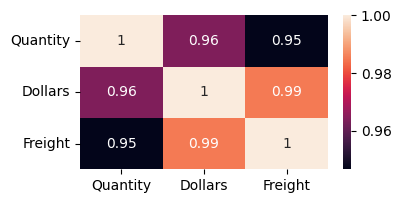

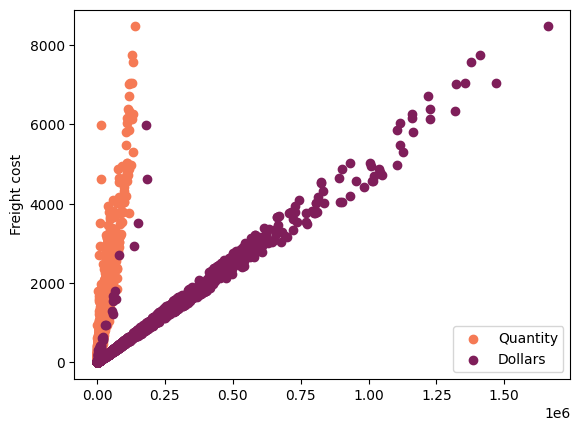

In [50]:
#Realtionship between dollars,freight,quantity
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(),annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'],vendor_df['Freight'],color='#f57a55')
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'],color='#7f1e5a')
plt.legend(['Quantity','Dollars'])
plt.ylabel("Freight cost")
plt.show()

#both the quantity and the dollars are the important predictor but dollars give more linear relationshiop and the quantity gives more variablity as it can affect due to other factor because in this the product with the same quantity cost differently so there is the other factors also which are affceting like the weight of the boththe product having with the same quantity varies so here the hidden factor may be the weight 

In [51]:
#;ets create a column where a vendor has to pay for a one unit 
vendor_df['Freight_per_unit']=vendor_df['Freight']/vendor_df['Quantity']
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809


In [52]:
low_quantity=vendor_df['Quantity'].quantile(0.25)
high_quantity=vendor_df['Quantity'].quantile(0.75)

In [53]:
low_quantity

83.0

In [54]:
high_quantity

5100.5

In [55]:
#“Give me the Freight_per_unit values where Quantity is less than low_quantity”
#df.loc[rows_condition, column_name] filter the rows and select the column 
vendor_df.loc[vendor_df['Quantity']<low_quantity,'Freight_per_unit'].mean()

0.09489854253138316

In [56]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'Freight_per_unit'].mean()

0.049077654690759046

we can see that when the vendor orders in the bulk he has to pay low freight cost as compared to when vendors order in low quantity

In [93]:
X=vendor_df[['Dollars']]
y=vendor_df['Freight']

In [94]:
from  sklearn.model_selection import train_test_split

In [95]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [96]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [97]:
model1=LinearRegression()
model1.fit(X_train,y_train)

model2=DecisionTreeRegressor(random_state=42)
model2.fit(X_train,y_train)

model3=RandomForestRegressor(random_state=42)
model3.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [1]:
def evaluate_model(model,X_test,y_test,model_name):
    pred=model.predict(X_test)

    mae=mean_absolute_error(y_test,pred) #actual-predicted gives the error so average of tis error
    rmse=np.sqrt(mean_squared_error(y_test,pred)) #more strict than mae it squares the error and the error becomes the bigger nuber so it penalizes the model more 
    r2=r2_score(y_test,pred)*100 #multipies by 100 to show in percentage. it tells how well model explain sthe data . if 85 % then Model explains 85% of variation in data

    print(f"\n{model_name} Performance:")
    print(f"MAE   :{mae:.2f}")
    print(f"RMSE  :{rmse:.2f}")
    print(f"R2    :{r2:.2f}%")
#I created a reusable evaluation function that calculates MAE, RMSE, and R² score to assess model performance on test data. MAE measures average error, RMSE penalizes large errors, and R² indicates how well the model explains variance.”
#Good model:

#Low MAE ✅
#Low RMSE ✅
#High R² ✅  

In [98]:
def evaluate_model(model,X_test,y_test,model_name):
    pred=model.predict(X_test)

    mae=mean_absolute_error(y_test,pred) #actual-predicted gives the error so average of tis error
    rmse=np.sqrt(mean_squared_error(y_test,pred)) #more strict than mae it squares the error and the error becomes the bigger nuber so it penalizes the model more 
    r2=r2_score(y_test,pred)*100 #multipies by 100 to show in percentage. it tells how well model explain sthe data . if 85 % then Model explains 85% of variation in data

    print(f"\n{model_name} Performance:")
    print(f"MAE   :{mae:.2f}")
    print(f"RMSE  :{rmse:.2f}")
    print(f"R2    :{r2:.2f}%")
#I created a reusable evaluation function that calculates MAE, RMSE, and R² score to assess model performance on test data. MAE measures average error, RMSE penalizes large errors, and R² indicates how well the model explains variance.”
#Good model:

#Low MAE ✅
#Low RMSE ✅
#High R² ✅  

In [99]:
evaluate_model(model1,X_test,y_test,'Linear Regression')
evaluate_model(model2,X_test,y_test,'Decision Tree Regressor')
evaluate_model(model3,X_test,y_test,'Random Forest Regressor')


Linear Regression Performance:
MAE   :24.11
RMSE  :124.72
R2    :96.99%

Decision Tree Regressor Performance:
MAE   :32.65
RMSE  :163.74
R2    :94.81%

Random Forest Regressor Performance:
MAE   :28.27
RMSE  :142.21
R2    :96.08%


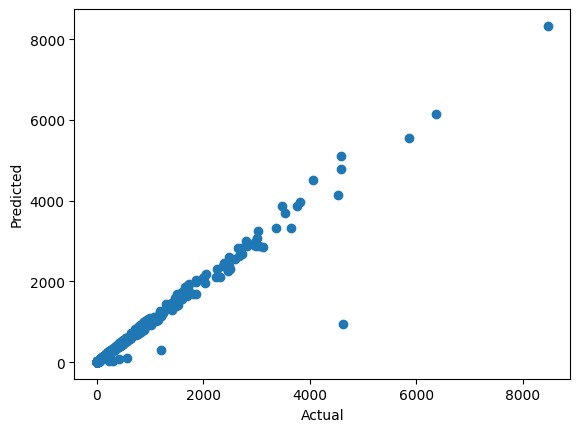

In [100]:
pred = model1.predict(X_test)

plt.scatter(y_test, pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [101]:
#inferencing:using a trained model to predict on new or unseen data
#lets crete a input data and ask model to predict the Freight cost 
input_data={
    'Dollars':[18500,9000],
}
df=pd.DataFrame(input_data)
model1.predict(df)

array([97.78868161, 50.14455838])